# Negatives-source heatmaps

One heatmap per block, side by side — pointwise and pairwise here, though the block list
below decides how many there are and what each one scores. Rows are where the *negative*
ideas came from (human, or a generation backbone); columns are judge models; each cell is
that judge's absolute score, not a delta.

It answers a different question from [two_track_figure.ipynb](two_track_figure.ipynb),
which holds the negatives fixed and varies the ablation. Here the ablation is fixed at the
baseline prompt and the negatives move, so the figure shows how far judge quality travels
as the thing being discriminated against gets stronger. It is drawn in that figure's
style — same palette, same inch-exact cell geometry, same typography — so the two sit
together in the paper.

Numbers are read straight from the `unified_<setup>_<variant>.json` files a merge writes.
Nothing is recomputed here — no merge re-run, no bootstrap.

Everything the figure says — rows, judges, metrics, titles, axis names, geometry — lives
in the one config cell below.

One thing the caption still has to carry: the human row comes from a different merge, and
therefore a different test set, than the generated rows. The figure sets that row apart
above the grid, the way `two_track_figure` sets apart its baseline strip, but only the
caption can say why.


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "src").is_dir() and (p / "output").is_dir()
)
sys.path.insert(0, str(ROOT / "src"))

# The red→green palette, the typeface, the Type-42 font settings, the shade at
# which cell text turns white and the save path — all shared with every other
# figure, so a regenerated panel cannot drift from the ones beside it.
from novelty_eval.figures.common import (
    FONT_STACK, PDF_RCPARAMS, WHITE_TEXT_BAND, delta_cmap, save_figure)


In [2]:
# ---- everything the chart says, in one place ---------------------------------

# Merge output directories. The row specs below refer to these names.
TRACKS = {
    "human":     ROOT / "output/ablation_sweeps/merge_hvh_all_metrics",
    "generated": ROOT / "output/ablation_sweeps/merge_vanilla_all_metrics",
}
# Which accuracy report the numbers came from: "filtered" or "unfiltered".
VARIANT = "filtered"

# The blocks of the figure, left to right: (block title, setup, metric key).
# The title is free text, and the only place the figure says which metric a block
# shows. Two blocks may share a setup, so showing accuracy beside strict accuracy
# is a matter of listing both. Metric keys (the next cell prints these):
#   pointwise  accuracy, f1_macro, f1_pos, f1_neg,
#              precision_pos, precision_neg, recall_pos, recall_neg
#   pairwise   pairwise_accuracy, pairwise_accuracy_strict, pairwise_accuracy_no_ties
BLOCKS = [
    ("Pointwise — Macro-F1", "pointwise", "f1_macro"),
    ("Pairwise — Accuracy (ties are failures)", "pairwise", "pairwise_accuracy_strict"),
]

# Rows, top to bottom: where the negative ideas came from.
# (label, track, panel). panel=None takes the track's un-ablated numbers; a panel
# name takes that panel's post-ablation numbers, {setup} expanding per block.
ROWS = [
    ("Human",      "human",     None),
    ("sonnet-4-5", "generated", None),
    ("opus-4-5",   "generated", "opus-4-5_backbone_{setup}_vanilla"),
    ("gpt-5.1",    "generated", "gpt_5.1_backbone_{setup}_vanilla"),
    ("gpt-5.4",    "generated", "gpt_5.4_backbone_{setup}_vanilla"),
]

# Judge columns, left to right: name in the data -> column header. The vendor
# prefix carries no information here, since every column is a judge.
JUDGES = {
    "claude-sonnet-4-5": "sonnet-4-5",
    "claude-opus-4-5":   "opus-4-5",
    "claude-opus-4-6":   "opus-4-6",
    "gpt-5.1":           "gpt-5.1",
    "gpt-5.2":           "gpt-5.2",
    "gpt-5.4":           "gpt-5.4",
}

# The row to set apart, drawn above the grid with a gap under it and labelled in
# italic — the human negatives come from a different merge, and so a different
# test set, than the generated rows. None makes it an ordinary row of the grid.
REFERENCE_ROW = "Human"

# The same model names appear as generators in the rows and as judges in the
# columns, so both axes need naming. "" drops either title.
ROW_AXIS_LABEL = "Negatives source"
COL_AXIS_LABEL = "Judge model"

# The scale is white at CENTER (50 = chance on a two-way decision), red below and
# green above, and shared by every block, so a shade means the same score wherever
# it appears. PAD is headroom in points past the extreme cells, so neither end of
# the palette is reached flat.
CENTER, PAD = 50.0, 2.0

# Layout in inches, so a cell is the size it says it is: every gap on the page is
# one number here, and there is no layout engine to reverse-engineer when it looks
# wrong. Cell height, gutter and type sizes match two_track_figure, so the two
# figures read as one family.
WIDTH_IN = 7.1                    # about full text width
CELL_IN = 0.44                    # height of one row
GAP_ROWS = 0.10                   # blank space under the reference row, in rows
GUTTER_IN = 0.17                  # between blocks
MARGIN_IN = {"left": 0.70,        # room for the row names and the axis title
             "right": 0.05, "top": 0.40,
             "bottom": 0.42,      # room for the judge names below the grid
             "xlabel": 0.12}      # the column title, up from the bottom edge:
                                  # the slack between the two is its padding
FONT_SIZES = {"value": 7.0, "row": 6.6, "judge": 5.8, "title": 8.0, "axis": 7.2}

# Output subdirectory under output/figures/, and the filename prefix — named
# like the sibling figures' directories (controlled-study, prompt-design).
# The variant and the metric keys land in the filename too, so changing what
# BLOCKS shows writes a new file instead of overwriting the last one.
FIGURE = "negatives-source"
FORMATS = [".pdf", ".png"]        # PDF is vector, PNG is what displays inline


In [3]:
DATA = {
    (track, setup): json.loads(
        (path / "unified_charts" / f"unified_{setup}_{VARIANT}.json").read_text()
    )
    for track, path in TRACKS.items()
    for setup in {setup for _, setup, _ in BLOCKS}
}

# The two lists a row or block spec has to spell correctly, printed so a typo in
# the config cell is one glance away rather than a KeyError to go hunting for.
for (track, setup), data in DATA.items():
    print(f"{track:>10}  {setup:<9}  metrics: {', '.join(data['available_metrics'])}")
    print(f"{'':>10}  {'':<9}  panels:  {', '.join(data['panels'])}\n")


     human  pointwise  metrics: accuracy, f1_macro, f1_pos, f1_neg, precision_pos, precision_neg, recall_pos, recall_neg, support, cost_usd
                       panels:  vague_criterion, no_criteria_prompt, retrieval, low_judge_reasoning, mec_k_1, convert_to_plan_form_pointwise_human

     human  pairwise   metrics: pairwise_accuracy, pairwise_accuracy_strict, pairwise_accuracy_no_ties, n_ties, support, cost_usd
                       panels:  vague_criterion, no_criteria_prompt, ai_researcher_base, ai_researcher_no_review, ai_researcher_comparative, retrieval, low_judge_reasoning, unidirectional, mec_k_1, convert_to_plan_form_pairwise_human

 generated  pointwise  metrics: accuracy, f1_macro, f1_pos, f1_neg, precision_pos, precision_neg, recall_pos, recall_neg, support, cost_usd
                       panels:  vague_criterion, no_criteria_prompt, retrieval, low_judge_reasoning, mec_k_1, convert_to_plan_form_pointwise_vanilla, gpt_5.1_backbone_pointwise_vanilla, gpt_5.4_backbone_poin

In [4]:
def score(track, panel, setup, judge, metric):
    """One cell, as a percentage. NaN when that judge has no number here."""
    panels = DATA[(track, setup)]["panels"]
    if panel is None:
        # Every panel in a track carries the same baseline, so the first panel
        # that has this judge answers for all of them.
        metrics = next((p["baseline_metrics"][judge] for p in panels.values()
                        if judge in p["baseline_metrics"]), {})
    else:
        metrics = panels[panel.format(setup=setup)]["ablation_metrics"].get(judge, {})
    value = metrics.get(metric)
    return np.nan if value is None else value * 100

TABLES = [
    (title, pd.DataFrame(
        [[score(track, panel, setup, judge, metric) for judge in JUDGES]
         for _, track, panel in ROWS],
        index=[label for label, _, _ in ROWS],
        columns=list(JUDGES.values()),
    ))
    for title, setup, metric in BLOCKS
]

# The whole data path, before any drawing: if a cell in the figure looks wrong,
# the reason is visible here.
for title, table in TABLES:
    print(title, "\n", table.round(1), "\n")


Pointwise — Macro-F1 
             sonnet-4-5  opus-4-5  opus-4-6  gpt-5.1  gpt-5.2  gpt-5.4
Human             60.7      70.7      80.6     75.2     64.4     66.6
sonnet-4-5        69.1      78.4      88.9     75.0     64.5     70.5
opus-4-5          66.4      72.6      84.4     65.0     61.8     70.1
gpt-5.1           53.9      59.2      72.8     50.5     57.7     64.2
gpt-5.4           53.1      44.3      59.6     34.6     52.6     66.5 

Pairwise — Accuracy (ties are failures) 
             sonnet-4-5  opus-4-5  opus-4-6  gpt-5.1  gpt-5.2  gpt-5.4
Human             74.0      79.2      82.5     83.8     83.8     83.1
sonnet-4-5        39.6      63.0      86.4     63.0     76.0     77.9
opus-4-5          18.2      45.4      68.8     47.4     55.8     57.8
gpt-5.1            3.2      24.0      49.4     23.4     28.6     34.4
gpt-5.4            4.6      20.8      38.3     11.7     19.5     18.2 



output/figures/negatives-source/negatives-source_filtered_f1_macro_pairwise_accuracy_strict.pdf
output/figures/negatives-source/negatives-source_filtered_f1_macro_pairwise_accuracy_strict.png


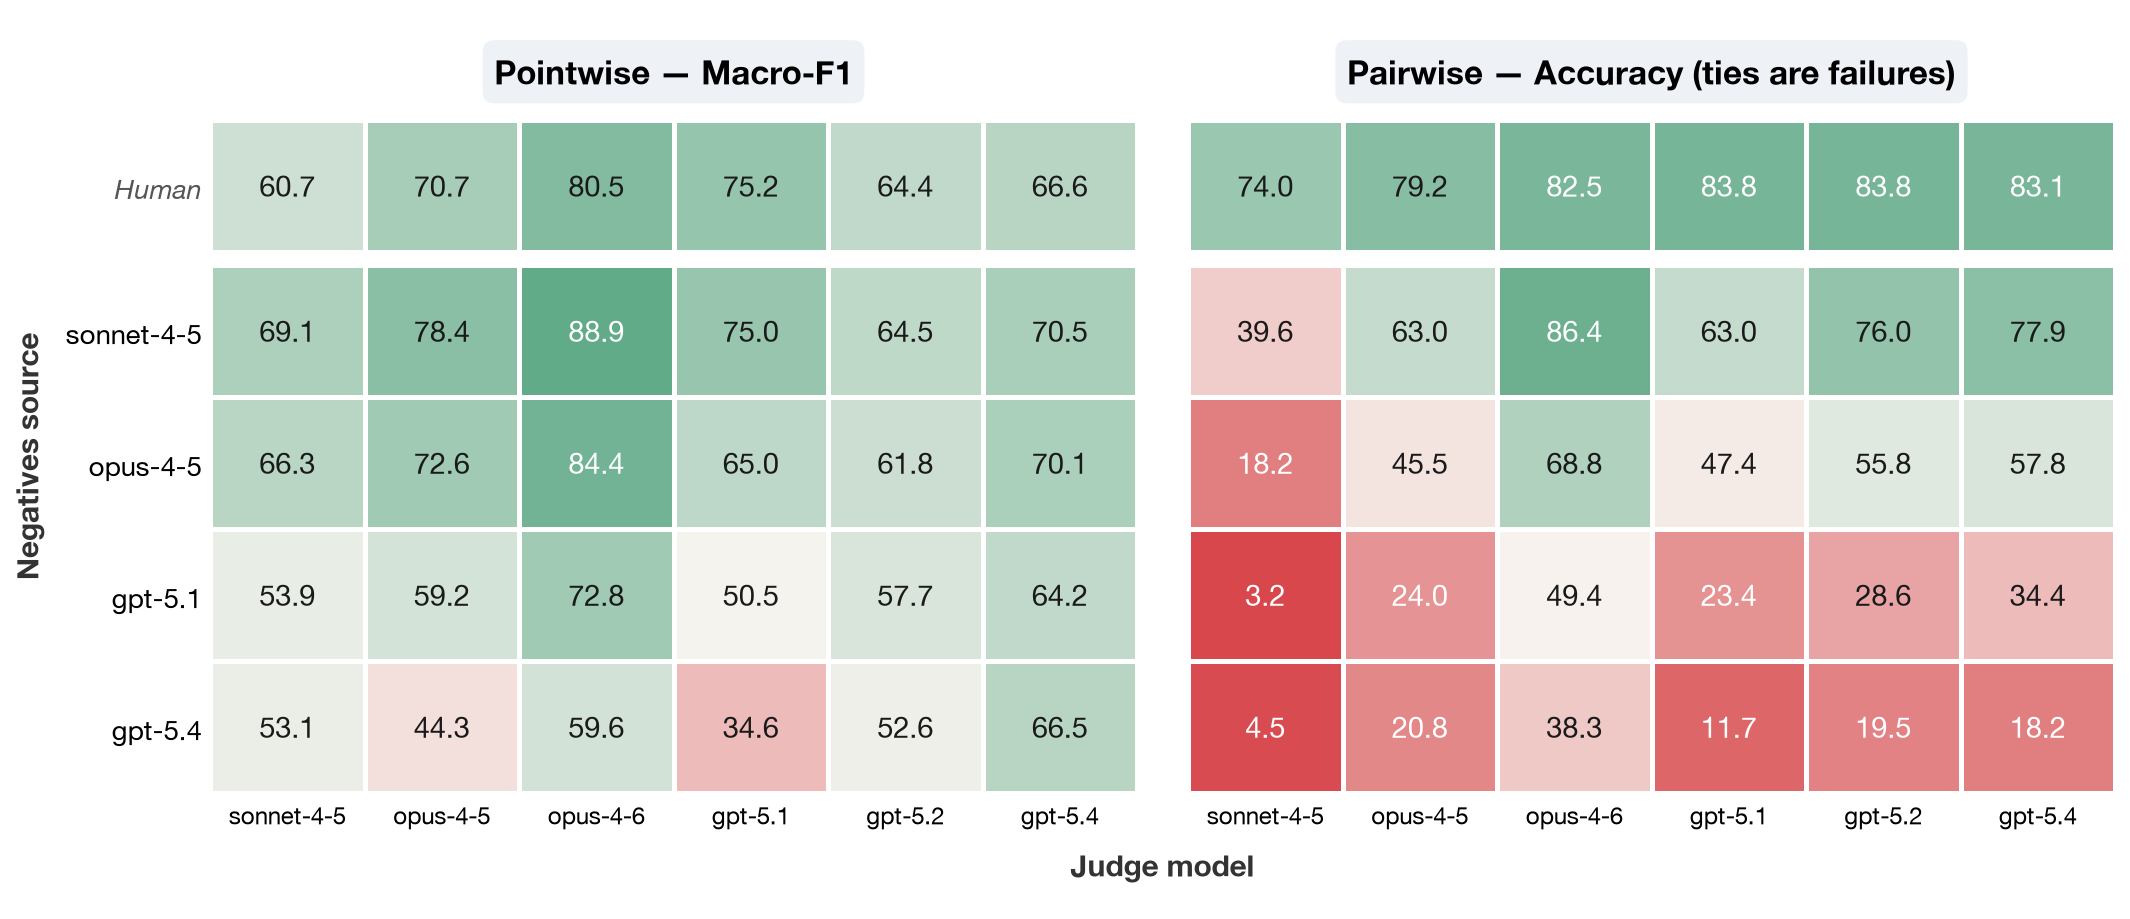

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": FONT_STACK, **PDF_RCPARAMS})

# One scale for every number on the page, symmetric about CENTER, so red means
# "below chance" rather than "low in whatever range this figure happens to cover".
values = np.concatenate([t.to_numpy(float).ravel() for _, t in TABLES])
span = np.nanmax(np.abs(values - CENTER)) + PAD
vmin, vmax = CENTER - span, CENTER + span
cmap, mesh_kw = delta_cmap(), dict(vmin=CENTER - span, vmax=CENTER + span,
                                   edgecolors="white", linewidth=1.2)

def text_colour(v):
    """Cell text: white only on the dark ends of the scale."""
    shade = (v - vmin) / (vmax - vmin)
    dark = shade < WHITE_TEXT_BAND[0] or shade > WHITE_TEXT_BAND[1]
    return "white" if dark else "#1a1a1a"

# The reference row sits above the grid with a gap under it, so it never reads as
# one more generated backbone. Row i is centred on y = i (+ the gap, below it).
rows = [label for label, _, _ in ROWS]
n_ref = 1 if REFERENCE_ROW in rows else 0
rows = ([REFERENCE_ROW] if n_ref else []) + [r for r in rows if r != REFERENCE_ROW]
gap = GAP_ROWS if n_ref else 0.0
y = [i + 0.5 + (gap if i >= n_ref else 0.0) for i in range(len(rows))]
n_col, n_grid = len(JUDGES), len(rows) - n_ref

grid_in = CELL_IN * (len(rows) + gap)
fig_h = grid_in + MARGIN_IN["top"] + MARGIN_IN["bottom"]
blocks_in = WIDTH_IN - MARGIN_IN["left"] - MARGIN_IN["right"]
block_in = (blocks_in - GUTTER_IN * (len(TABLES) - 1)) / len(TABLES)

fig = plt.figure(figsize=(WIDTH_IN, fig_h))
gs = fig.add_gridspec(1, len(TABLES), wspace=GUTTER_IN / block_in,
                      left=MARGIN_IN["left"] / WIDTH_IN,
                      right=1 - MARGIN_IN["right"] / WIDTH_IN,
                      top=1 - MARGIN_IN["top"] / fig_h,
                      bottom=MARGIN_IN["bottom"] / fig_h)

for k, (title, table) in enumerate(TABLES):
    ax = fig.add_subplot(gs[0, k])
    table = table.reindex(rows)
    cells = np.ma.masked_invalid(table.to_numpy(float))
    x = np.arange(n_col + 1)
    if n_ref:
        ax.pcolormesh(x, np.arange(n_ref + 1), cells[:n_ref], cmap=cmap, **mesh_kw)
    ax.pcolormesh(x, n_ref + gap + np.arange(n_grid + 1), cells[n_ref:],
                  cmap=cmap, **mesh_kw)

    for i, row in enumerate(rows):
        for j, judge in enumerate(table.columns):
            v = table.loc[row, judge]
            if not np.isfinite(v):
                ax.text(j + 0.5, y[i], "—", ha="center", va="center",
                        fontsize=6, color="#999999")
                continue
            # Set regular: weight is significance in the sibling figures, and
            # a score is not a claim about a change, so nothing here is bold.
            ax.text(j + 0.5, y[i], f"{v:.1f}", ha="center", va="center",
                    fontsize=FONT_SIZES["value"], color=text_colour(v))

    ax.set_xlim(0, n_col)
    ax.set_ylim(len(rows) + gap, 0)                  # first row at the top
    # Set horizontally: the longest judge name is narrower than a cell at this
    # size, so there is nothing for a rotation to rescue.
    ax.set_xticks(x[:-1] + 0.5, table.columns, fontsize=FONT_SIZES["judge"])
    ax.set_yticks(y, rows, fontsize=FONT_SIZES["row"])
    ax.set_title(title, fontsize=FONT_SIZES["title"], fontweight="bold",
                 pad=8.5, bbox=dict(boxstyle="round,pad=0.35", fc="#eef1f5",
                                    ec="none"))
    ax.tick_params(length=0, pad=2)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # The row names and both axis titles belong to the left-hand block only.
    if k:
        ax.tick_params(labelleft=False)
        continue
    for label in ax.get_yticklabels()[:n_ref]:
        label.set(style="italic", color="#555555")   # not one of the backbones
    if ROW_AXIS_LABEL:
        ax.set_ylabel(ROW_AXIS_LABEL, fontsize=FONT_SIZES["axis"],
                      fontweight="bold", color="#333333", labelpad=5)

if COL_AXIS_LABEL:
    fig.text((MARGIN_IN["left"] + blocks_in / 2) / WIDTH_IN,
             MARGIN_IN["xlabel"] / fig_h,
             COL_AXIS_LABEL, ha="center", va="bottom",
             fontsize=FONT_SIZES["axis"], fontweight="bold", color="#333333")

stem = "_".join([FIGURE, VARIANT] + [metric for _, _, metric in BLOCKS])
out_path = ROOT / "output/figures" / FIGURE / (stem + FORMATS[0])
written = save_figure(fig, out_path, formats=FORMATS[1:])
print(*[p.relative_to(ROOT) for p in written], sep="\n")
display(Image(filename=str(next(p for p in written if p.suffix == ".png"))))
